In [1]:
pip install duckdb pandas scikit-learn shap matplotlib jupyter

Note: you may need to restart the kernel to use updated packages.


In [8]:
import duckdb
con = duckdb.connect()

# First, just peek — see the columns and confirm the delimiter before filtering
con.execute("""
    SELECT * FROM read_csv('en.openfoodfacts.org.products.csv', delim='\t', header=true,
                           ignore_errors=true, sample_size=-1)
    LIMIT 5
""").df()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,000000000054,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-25 05:30:31+11:00,1733085204,2024-12-02 07:33:24+11:00,None,1740205422,2025-02-22 17:23:42+11:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000000000063,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-14 01:31:47+11:00,1750061386,2025-06-16 18:09:46+10:00,bodysupport,1750061386,2025-06-16 18:09:46+10:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000000000114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-27 06:21:22+11:00,1751035658,2025-06-28 00:47:38+10:00,teolemon,1751035658,2025-06-28 00:47:38+10:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,000000000431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28 20:55:12+10:00,1714301721,2024-04-28 20:55:21+10:00,kiliweb,1714301721,2024-04-28 20:55:21+10:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0000000105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-27 06:22:23+11:00,1738073570,2025-01-29 01:12:50+11:00,None,1743653496,2025-04-03 15:11:36+11:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
con.execute("""
    SELECT DISTINCT countries_en
    FROM read_csv('en.openfoodfacts.org.products.csv', delim='\t', header=true,
                  ignore_errors=true, sample_size=-1)
    WHERE countries_en ILIKE '%australia%'
    LIMIT 20
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,countries_en
0,"Australia,New Caledonia"
1,"Australia,New Caledonia,New Zealand"
2,"Australia,Singapore"
3,"Australia,France,New Zealand,Singapore,United ..."
4,"Australia,France,Spain,Sweden,Switzerland"
5,"Australia,Italy"
6,"Australia,Germany,Ireland,Morocco"
7,"Australia,France,New Zealand,Switzerland"
8,"Australia,Austria,Croatia,France,Germany"
9,"Australia,France,En"


In [11]:
import duckdb
con = duckdb.connect()

con.execute("""
COPY (
    SELECT
        code, product_name, brands, categories_en, countries_en,
        nutriscore_grade, nutriscore_score, nova_group,
        "energy-kcal_100g"   AS energy_kcal_100g,
        fat_100g,
        "saturated-fat_100g" AS saturated_fat_100g,
        sugars_100g, fiber_100g, proteins_100g, salt_100g, sodium_100g,
        carbohydrates_100g,
        ingredients_text, additives_n, labels_en
    FROM read_csv('en.openfoodfacts.org.products.csv', delim='\t', header=true,
                  ignore_errors=true, sample_size=-1)
    WHERE (countries_en ILIKE '%australia%' OR countries_tags ILIKE '%australia%')
      AND (nova_group IS NOT NULL OR nutriscore_grade IN ('a','b','c','d','e'))
) TO 'au_food_raw.csv' (HEADER, DELIMITER ',');
""")

print("done")



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

done


In [12]:
import pandas as pd
df = pd.read_csv('au_food_raw.csv')

# How many have the core nutrition fields we'll model on?
core = ['energy_kcal_100g','fat_100g','saturated_fat_100g','sugars_100g','proteins_100g','salt_100g']
print("Total rows:", len(df))
print("Rows with all core nutrition:", df.dropna(subset=core).shape[0])
print("\nTarget availability:")
print("  have nova_group:      ", df['nova_group'].notna().sum())
print("  have nutriscore_grade:", df['nutriscore_grade'].notna().sum())

Total rows: 17225
Rows with all core nutrition: 4904

Target availability:
  have nova_group:       12665
  have nutriscore_grade: 17225


In [13]:
import pandas as pd
df = pd.read_csv('au_food_raw.csv')

core = ['energy_kcal_100g','fat_100g','saturated_fat_100g','sugars_100g','proteins_100g','salt_100g']

# rows usable for a NOVA model = have NOVA target AND all core nutrition
nova_ready = df.dropna(subset=core + ['nova_group'])
print("NOVA-ready rows:", len(nova_ready))
print("NOVA class balance:\n", nova_ready['nova_group'].value_counts().sort_index())

# rows usable for a Nutri-Score model
nutri_ready = df.dropna(subset=core + ['nutriscore_grade'])
print("\nNutri-Score-ready rows:", len(nutri_ready))
print("Nutri-Score class balance:\n", nutri_ready['nutriscore_grade'].value_counts().sort_index())

NOVA-ready rows: 3731
NOVA class balance:
 nova_group
1.0     348
2.0      83
3.0     598
4.0    2702
Name: count, dtype: int64

Nutri-Score-ready rows: 4904
Nutri-Score class balance:
 nutriscore_grade
a                  680
b                  498
c                  994
d                  748
e                 1052
not-applicable     179
unknown            753
Name: count, dtype: int64


In [14]:
import pandas as pd
df = pd.read_csv('au_food_raw.csv')

core = ['energy_kcal_100g','fat_100g','saturated_fat_100g','sugars_100g','proteins_100g','salt_100g']

# Keep only rows with real grades + full nutrition
valid = ['a','b','c','d','e']
model_df = df[df['nutriscore_grade'].isin(valid)].dropna(subset=core).copy()
print("Clean modelling rows:", len(model_df))
print(model_df['nutriscore_grade'].value_counts().sort_index())

Clean modelling rows: 3972
nutriscore_grade
a     680
b     498
c     994
d     748
e    1052
Name: count, dtype: int64


In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv('au_food_raw.csv')

core = ['energy_kcal_100g','fat_100g','saturated_fat_100g','sugars_100g','proteins_100g','salt_100g']
valid = ['a','b','c','d','e']
model_df = df[df['nutriscore_grade'].isin(valid)].dropna(subset=core).copy()

# --- Sanity filters: remove physically impossible values (data-quality step) ---
for col in ['fat_100g','saturated_fat_100g','sugars_100g','proteins_100g']:
    model_df = model_df[model_df[col].between(0, 100)]
model_df = model_df[model_df['energy_kcal_100g'].between(0, 900)]

# --- Engineered numeric features (your nutrition knowledge as columns) ---
model_df['sat_fat_ratio']   = model_df['saturated_fat_100g'] / model_df['fat_100g'].replace(0, np.nan)
model_df['protein_density'] = model_df['proteins_100g'] / model_df['energy_kcal_100g'].replace(0, np.nan)
model_df['sugar_density']   = model_df['sugars_100g'] / model_df['energy_kcal_100g'].replace(0, np.nan)
model_df['fiber_100g']      = model_df['fiber_100g'].fillna(0)      # missing fibre ≈ none declared
model_df['additives_n']     = model_df['additives_n'].fillna(0)
model_df['has_additives']   = (model_df['additives_n'] > 0).astype(int)

# --- Ingredient-text features (cheap signals of processing) ---
ing = model_df['ingredients_text'].fillna('').str.lower()
model_df['n_ingredients']   = ing.str.count(',') + 1
model_df['has_added_sugar'] = ing.str.contains('sugar|syrup|glucose|fructose|dextrose').astype(int)
model_df['has_palm_oil']    = ing.str.contains('palm').astype(int)

# --- "Looks healthy" marketing flag (backbone of the health-halo page) ---
health_words = r'natural|wholesome|lite|light|protein|guilt|wellness|pure|clean|organic|skinny|superfood'
name = model_df['product_name'].fillna('').str.lower()
labels = model_df['labels_en'].fillna('').str.lower()
model_df['claims_healthy'] = (name.str.contains(health_words) | labels.str.contains(health_words)).astype(int)

model_df = model_df.replace([np.inf, -np.inf], np.nan)
print("Rows after feature engineering:", len(model_df))
print("Claims-healthy products:", model_df['claims_healthy'].sum())
model_df.to_csv('au_food_model.csv', index=False)

Rows after feature engineering: 3956
Claims-healthy products: 501


In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

features = ['energy_kcal_100g','fat_100g','saturated_fat_100g','sugars_100g',
            'fiber_100g','proteins_100g','salt_100g','sat_fat_ratio',
            'protein_density','sugar_density','additives_n','has_additives',
            'n_ingredients','has_added_sugar','has_palm_oil']

X = model_df[features]
y = model_df['nutriscore_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = HistGradientBoostingClassifier(random_state=42)   # handles NaNs natively
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

# 5-fold cross-validation for a more honest accuracy estimate
cv = cross_val_score(model, X, y, cv=5)
print(f"CV accuracy: {cv.mean():.3f} (+/- {cv.std():.3f})")

python(40031) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40032) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


              precision    recall  f1-score   support

           a       0.83      0.87      0.85       136
           b       0.65      0.55      0.59       100
           c       0.72      0.77      0.74       198
           d       0.78      0.80      0.79       149
           e       0.92      0.88      0.89       209

    accuracy                           0.79       792
   macro avg       0.78      0.77      0.77       792
weighted avg       0.79      0.79      0.79       792

CV accuracy: 0.765 (+/- 0.027)


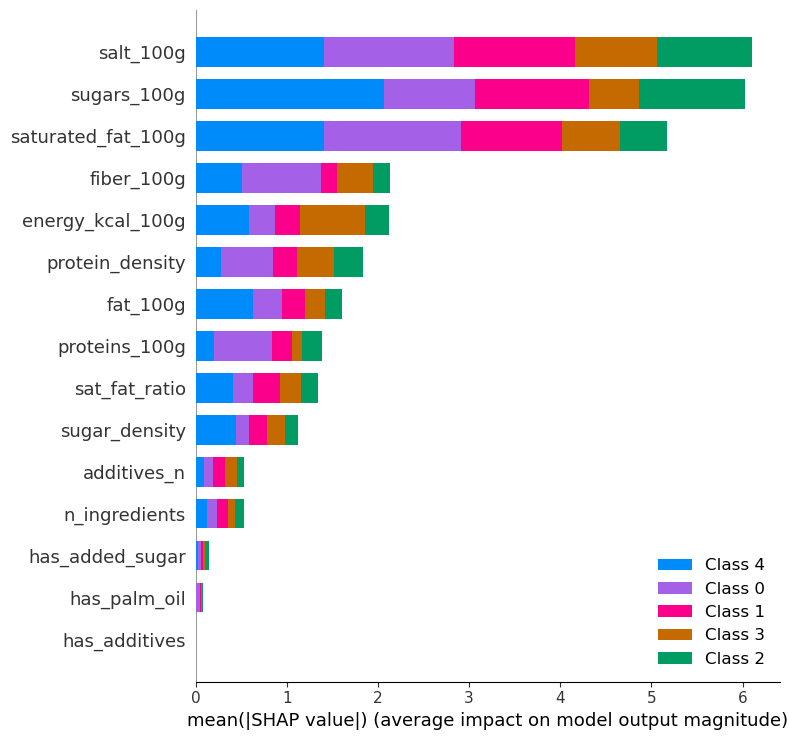

In [18]:
import shap, matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout(); plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
import pandas as pd
df = pd.read_csv('au_food_model.csv')

# "Actually unhealthy" = scores D or E
df['actually_unhealthy'] = df['nutriscore_grade'].isin(['d','e']).astype(int)

# The halo offenders: marketed as healthy BUT score D/E
halo = df[(df['claims_healthy'] == 1) & (df['actually_unhealthy'] == 1)].copy()

# The headline stat
pct = len(halo) / df[df['claims_healthy']==1].shape[0]
print(f"{df['claims_healthy'].sum()} products use 'healthy' marketing language")
print(f"{len(halo)} of them actually score D or E")
print(f"=> {pct:.0%} of 'healthy-marketed' products are actually poorly rated")

# Save the offender list for the dashboard
halo_out = halo[['product_name','brands','categories_en','nutriscore_grade',
                 'sugars_100g','salt_100g','saturated_fat_100g','additives_n']]
halo_out = halo_out.sort_values('nutriscore_grade', ascending=False)
halo_out.to_csv('health_halo.csv', index=False)
print("\nTop offenders:")
halo_out.head(10)

501 products use 'healthy' marketing language
165 of them actually score D or E
=> 33% of 'healthy-marketed' products are actually poorly rated

Top offenders:


,product_name,brands,categories_en,nutriscore_grade,sugars_100g,salt_100g,saturated_fat_100g,additives_n
2301,STACKERS LEG HAM CHEDDAR CHEESE & CRACKERS,Primo,"Snacks,Meats and their products,Salty snacks,A...",e,0.000000,2.010000,8.600000,9.0
3176,BUTTERSOFT 100% PURE BUTTER,MAINLAND,"Dairies,Fats,Spreads,Spreadable fats,Animal fa...",e,1.000000,0.480000,49.000000,0.0
2850,Naturally Soft Salted Butter,Pure Valley,"Dairies,Fats,Spreads,Spreadable fats,Animal fa...",e,1.000000,1.200000,49.100000,0.0
2896,Vegan dark cocoa,"Biona Organic, Biona","Breakfasts,Spreads,Sweet spreads,fr:Pâtes à ta...",e,51.000000,0.000000,5.700000,1.0
2138,Organic virgin coconut oil,planet food,"Plant-based foods and beverages,Plant-based fo...",e,0.000000,0.100000,86.100000,0.0
2128,Macadamia,Pana,"Snacks,Sweet snacks,Cocoa and its products,Cho...",e,24.500000,0.192500,22.200000,1.0
2127,Pana Cacao Menthe 45G Pana Cacao,PANA ORGANIC,"Snacks,Sweet snacks,Cocoa and its products,Con...",e,22.000000,0.066667,30.000000,0.0
2974,Mr Kipling 6 Cherry Bakewells,Mr Kipling,"Snacks,Desserts,Sweet snacks,Biscuits and cake...",e,38.300000,0.000356,7.100000,13.0
3053,Light Coconut Milk,AYAM,"Plant-based foods and beverages,Beverages,Plan...",e,1.714286,0.121429,14.857143,0.0
3064,"Curry Paste For Beef Rendang, Medium",Ayam,"Condiments,Sauces,Meal sauces,Curry pastes,Gro...",e,8.700000,4.086860,5.430000,0.0


In [20]:
import pandas as pd
df = pd.read_csv('au_food_model.csv')

# Tighter "health-positioning" language — drop 'pure','natural','organic','clean' which over-catch whole foods
health_words = r'lite|light|wellness|guilt|skinny|superfood|protein|wholesome|low.?fat|low.?sugar|diet|slim|nutritious'
name   = df['product_name'].fillna('').str.lower()
labels = df['labels_en'].fillna('').str.lower()
df['claims_healthy'] = (name.str.contains(health_words) | labels.str.contains(health_words)).astype(int)

# Exclude honestly-labelled whole-food fats/oils/butters (not health-halo cases)
whole_food = df['categories_en'].fillna('').str.lower().str.contains('butter|cooking oil|olive oil|coconut oil|animal fats')
df.loc[whole_food, 'claims_healthy'] = 0

df['actually_unhealthy'] = df['nutriscore_grade'].isin(['d','e']).astype(int)
halo = df[(df['claims_healthy']==1) & (df['actually_unhealthy']==1)].copy()

n_healthy = df['claims_healthy'].sum()
pct = len(halo)/n_healthy if n_healthy else 0
print(f"{n_healthy} products use health-positioning language")
print(f"{len(halo)} score D or E => {pct:.0%}")

halo[['product_name','brands','categories_en','nutriscore_grade',
      'sugars_100g','salt_100g','saturated_fat_100g','additives_n']]\
    .sort_values('sugars_100g', ascending=False).to_csv('health_halo.csv', index=False)
halo.sort_values('sugars_100g', ascending=False)[['product_name','brands','nutriscore_grade','sugars_100g']].head(10)

226 products use health-positioning language
69 score D or E => 31%


,product_name,brands,nutriscore_grade,sugars_100g
322,Turkish Delight,Cadbury Dairy Milk,e,55.200
2826,Lindt Creation Chocolate Block Hazelnut Delight,Lindt,e,53.000
350,FRY'S TURKISH DELIGHT,Cadbury,e,52.000
349,FYR'S TURKISH DELIGHT,Cadbury,e,51.800
335,OLD GOLD DARK CHOCOLATE,Cadbury,e,48.800
3469,Salted Caramel Protein Bar,Tasti,e,46.875
3468,Coconut Delight Bar,Weight Watchers,e,37.000
1866,ICED CHOCOLATE FLAVOURED MILK,Nippy's,e,32.600
118,Protein Oat Bar,Hillcrest,e,27.250
1582,Superfood Snacking Mix,Coles,d,23.300


In [21]:
import pandas as pd, numpy as np

model_df = pd.read_csv('au_food_model.csv')

# 1) Main table for the landscape + filtering pages (already saved as au_food_model.csv) — no action needed

# 2) Feature importance (rebuild the ranking natively in Power BI as a bar)
#    Re-derive from the SHAP magnitudes you already computed, or hard-code the ranking:
imp = pd.DataFrame({
    'feature': ['salt_100g','sugars_100g','saturated_fat_100g','fiber_100g','energy_kcal_100g',
                'protein_density','fat_100g','proteins_100g','sat_fat_ratio','sugar_density',
                'additives_n','n_ingredients','has_added_sugar','has_palm_oil','has_additives'],
    'importance': [6.0,5.9,5.2,2.1,2.0,1.8,1.6,1.4,1.3,1.1,0.5,0.5,0.1,0.05,0.02]  # approx from your SHAP chart
})
imp.to_csv('feature_importance.csv', index=False)

# 3) health_halo.csv — already saved in Stage 4 ✅

# 4) Tiny metrics table for KPI cards
metrics = pd.DataFrame({
    'metric': ['CV Accuracy','Grade A recall','Grade E recall','Health-halo %','Products analysed'],
    'value':  ['77%','0.87','0.88','31%', str(len(model_df))]
})
metrics.to_csv('model_metrics.csv', index=False)

print("Exported: au_food_model.csv, feature_importance.csv, health_halo.csv, model_metrics.csv")

Exported: au_food_model.csv, feature_importance.csv, health_halo.csv, model_metrics.csv
